In [56]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/breast-cancer-dataset/breast-cancer.csv


In [57]:
df = pd.read_csv('/kaggle/input/datasets/yasserh/breast-cancer-dataset/breast-cancer.csv')

In [58]:
pd.set_option('display.max_columns', None)
df.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
395,903811,B,14.060,17.18,89.75,609.1,0.08045,0.05361,0.02681,0.03251,0.1641,0.05764,0.1504,1.6850,1.237,12.67,0.005371,0.012730,0.01132,0.009155,0.01719,0.001444,14.92,25.34,96.42,684.5,0.1066,0.12310,0.08460,0.07911,0.2523,0.06609
67,859465,B,11.310,19.04,71.80,394.1,0.08139,0.04701,0.03709,0.02230,0.1516,0.05667,0.2727,0.9429,1.831,18.15,0.009282,0.009216,0.02063,0.008965,0.02183,0.002146,12.33,23.84,78.00,466.7,0.1290,0.09148,0.14440,0.06961,0.2400,0.06641
378,9013594,B,13.660,15.15,88.27,580.6,0.08268,0.07548,0.04249,0.02471,0.1792,0.05897,0.1402,0.5417,1.101,11.35,0.005212,0.029840,0.02443,0.008356,0.01818,0.004868,14.54,19.64,97.96,657.0,0.1275,0.31040,0.25690,0.10540,0.3387,0.09638
533,91930402,M,20.470,20.67,134.70,1299.0,0.09156,0.13130,0.15230,0.10150,0.2166,0.05419,0.8336,1.7360,5.168,100.40,0.004938,0.030890,0.04093,0.016990,0.02816,0.002719,23.23,27.15,152.00,1645.0,0.1097,0.25340,0.30920,0.16130,0.3220,0.06386
234,882488,B,9.567,15.91,60.21,279.6,0.08464,0.04087,0.01652,0.01667,0.1551,0.06403,0.2152,0.8301,1.215,12.64,0.011640,0.010400,0.01186,0.009623,0.02383,0.003540,10.51,19.16,65.74,335.9,0.1504,0.09515,0.07161,0.07222,0.2757,0.08178


In [59]:
df = df.drop(columns = ['id'])
df.columns.to_list()

['diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

In [60]:
df.shape

(569, 31)

In [61]:
# Features and Target
X = df.drop(columns = ['diagnosis'])
y = df.diagnosis

In [62]:
X.isnull().sum().sum()/df.size * 100

np.float64(0.0)

In [63]:
X.duplicated().sum()

np.int64(0)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [65]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [66]:
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [67]:
X.head(3)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [69]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X_TRAIN = scale.fit_transform(X_train)
X_TEST = scale.transform(X_test)

In [70]:
from sklearn.neighbors import KNeighborsClassifier

knn_classifier = KNeighborsClassifier(n_neighbors = 3)
knn_classifier.fit(X_TRAIN, y_train)

KNeighborsClassifier(n_neighbors=3)

In [71]:
y_pred = knn_classifier.predict(X_TEST)

In [72]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print('-'*40)

# Convert classes to a list of strings
string_target_names = [str(cls) for cls in knn_classifier.classes_]

print("Classification Report:\n", 
      classification_report(y_test, y_pred, target_names=string_target_names))


Accuracy: 0.9473684210526315
----------------------------------------
Classification Report:
               precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



### Choosing the best k-value

In [73]:
scores = list()

for i in range(1,20):
    clf = KNeighborsClassifier(n_neighbors=i)
    clf.fit(X_TRAIN, y_train)

    y_pred = clf.predict(X_TEST)
    scores.append(accuracy_score(y_test, y_pred))

In [74]:
scores

[0.9385964912280702,
 0.9473684210526315,
 0.9473684210526315,
 0.956140350877193,
 0.9473684210526315,
 0.956140350877193,
 0.9473684210526315,
 0.956140350877193,
 0.9649122807017544,
 0.956140350877193,
 0.956140350877193,
 0.956140350877193,
 0.956140350877193,
 0.956140350877193,
 0.956140350877193,
 0.9473684210526315,
 0.9473684210526315,
 0.9473684210526315,
 0.9473684210526315]

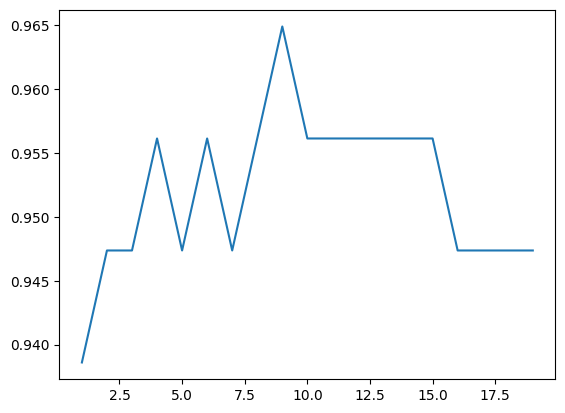

In [75]:
import matplotlib.pyplot as plt

plt.plot(range(1,20),scores)

In [84]:
knn_classifier = KNeighborsClassifier(n_neighbors = 9)
knn_classifier.fit(X_TRAIN, y_train)

y_pred = knn_classifier.predict(X_TEST)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print('-'*40)

# Convert classes to a list of strings
string_target_names = [str(cls) for cls in knn_classifier.classes_]

print("Classification Report:\n", 
      classification_report(y_test, y_pred, target_names=string_target_names))


Accuracy: 0.9649122807017544
----------------------------------------
Classification Report:
               precision    recall  f1-score   support

           B       0.97      0.97      0.97        71
           M       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



### Choosing best k-value using cross-validation

In [78]:
from sklearn.model_selection import GridSearchCV

params =  {
    'n_neighbors': range(1, 31),             
    'weights': ['uniform', 'distance'],      
    'metric': ['euclidean', 'manhattan']     
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv = 10,
    scoring = 'accuracy'
)

grid.fit(X_TRAIN, y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': range(1, 31),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [79]:
grid.best_params_

{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}

In [80]:
grid.best_score_

np.float64(0.971304347826087)

In [81]:
best_model = grid.best_estimator_

In [82]:
y_pred = best_model.predict(X_TEST)
accuracy_score(y_test, y_pred)

0.9473684210526315

In [ ]:
print("Average Accuracy:", scores.mean())
print("Accuracy Variance:", scores.std())
# A high standard deviation means the model performance relies heavily on how the data is split.

## Elbow Method

In [95]:
from sklearn.model_selection import cross_val_score

k_values = list(range(1, 20)) 
error_rates = list()

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors = k, weights = 'uniform')

    scores = cross_val_score(knn, X, y, cv = 5, scoring = 'accuracy')

    # Error rate
    mean_error = 1 - scores.mean()
    error_rates.append(mean_error)

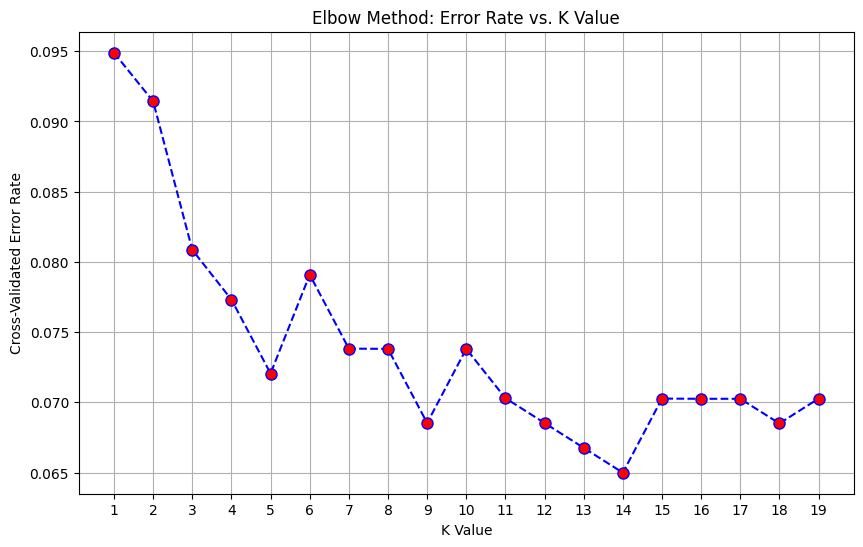

In [96]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rates, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)

plt.title('Elbow Method: Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Cross-Validated Error Rate')
# Show every number on the x-axis so it is clear
plt.xticks(k_values) 
plt.grid(True)
plt.show()

In [100]:
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X_TRAIN, y_train)
y_pred = knn.predict(X_TEST)
accuracy_score(y_test, y_pred)

0.956140350877193